In [1]:
import random
import tkinter as tk
from tkinter import messagebox
import matplotlib.pyplot as plt

# Constants
POPULATION_SIZE = 50
GENOME_LENGTH = 10  # Length of action sequence
MUTATION_RATE = 0.1
ELITISIM_COUNT = int((2/10)*POPULATION_SIZE)
PC = 0.9 #Crossover Probability
GENERATIONS = 100
A=0.05

GRID_SIZE = 20
CELL_SIZE = 25

ACTIONS = ['W', 'P', 'G', 'U', 'D', 'L', 'R']
ENEMY_ACTIONS = 'GGGLGUGGLR'  # Enemy's action sequence

class Game:
    def __init__(self, player_actions):
        self.player_points = 100
        self.enemy_points = 100
        self.turn = 0
        self.sequence = ""
        self.enemy_sequence = ""
        self.player_actions = player_actions
        self.enemy_war_once = False  # Track if enemy has used War once
        self.player_war_once = False  # Track if enemy has used War once
        self.x_player = GRID_SIZE // 2
        self.y_player = GRID_SIZE // 2
        self.x_enemy = (GRID_SIZE // 2) + 1
        self.y_enemy = GRID_SIZE // 2

    def calculate_points(self, player_action, enemy_action):
        # Calculate effects of player actions
        if player_action == 'W' and self.x_player == self.x_enemy and self.y_player == self.y_enemy:
            self.player_points += (self.enemy_points * A + self.player_points * A)
            self.enemy_points -= (self.enemy_points * A + self.player_points * A * 2)
            self.player_war_once = True 
        elif player_action == 'P' and self.x_player == self.x_enemy and self.y_player == self.y_enemy:
            self.player_points -= (self.player_points * A)
            self.enemy_points += (self.player_points * A)
        elif player_action == 'G':
            self.player_points += (self.player_points * A)
        elif player_action == 'U':
            self.player_points -= (self.player_points * A)
            self.y_player = max(0, self.y_player - 1)
        elif player_action == 'D':
            self.player_points -= (self.player_points * A)
            self.y_player = min(GRID_SIZE - 1, self.y_player + 1)
        elif player_action == 'L':
            self.player_points -= (self.player_points * A)
            self.x_player = max(0, self.x_player - 1)
        elif player_action == 'R':
            self.player_points -= (self.player_points * A)
            self.x_player = min(GRID_SIZE - 1, self.x_player + 1)

        # Calculate effects of enemy actions
        if enemy_action == 'W' and self.x_player == self.x_enemy and self.y_player == self.y_enemy:
            self.enemy_points += (self.enemy_points * A + self.player_points * A)
            self.player_points -= (self.enemy_points * A + self.player_points * A * 2)
        elif enemy_action == 'P' and self.x_player == self.x_enemy and self.y_player == self.y_enemy:
            self.enemy_points -= (self.enemy_points * A)
            self.player_points += (self.enemy_points * A)
        elif enemy_action == 'G':
            self.enemy_points += (self.enemy_points * A)
        elif enemy_action == 'U':
            self.enemy_points -= (self.enemy_points * A)
            self.y_enemy = max(0, self.y_enemy - 1)
        elif enemy_action == 'D':
            self.enemy_points -= (self.enemy_points * A)
            self.y_enemy = min(GRID_SIZE - 1, self.y_enemy + 1)
        elif enemy_action == 'L':
            self.enemy_points -= (self.enemy_points * A)
            self.x_enemy = max(0, self.x_enemy - 1)
        elif enemy_action == 'R':
            self.enemy_points -= (self.enemy_points * A)
            self.x_enemy = min(GRID_SIZE - 1, self.x_enemy + 1)
            
    def play_turn(self, player_action):
        enemy_action = ENEMY_ACTIONS[self.turn]

        # Check for enemy using "War" if not already used and if on the same cell
        if not self.enemy_war_once and self.x_player == self.x_enemy and self.y_player == self.y_enemy:
            enemy_action = 'W'
            self.enemy_war_once = True

        # Calculate points and actions
        self.calculate_points(player_action, enemy_action)

        # Track sequences
        self.sequence += player_action
        self.enemy_sequence += enemy_action
        self.turn += 1

        return self.player_points, self.enemy_points, self.sequence, self.enemy_sequence, (self.x_player, self.y_player), (self.x_enemy, self.y_enemy)

    def play(self):
        for action in self.player_actions:
            if self.turn < GENOME_LENGTH:
                enemy_action = ENEMY_ACTIONS[self.turn]
                self.calculate_points(action, enemy_action)
                self.sequence += action
                self.enemy_sequence += enemy_action
                self.turn += 1
        return self.player_points, self.enemy_points, self.sequence, self.enemy_sequence

import tkinter as tk
from tkinter import messagebox

# Assuming `Game`, `ACTIONS`, `GRID_SIZE`, `CELL_SIZE`, and `GENOME_LENGTH` are already defined.

class GameInterface:
    def __init__(self, root):
        self.root = root
        self.root.title("Game Theory Interface")

        self.game = Game([''] * GENOME_LENGTH)

        self.canvas = tk.Canvas(root, width=GRID_SIZE * CELL_SIZE, height=GRID_SIZE * CELL_SIZE)
        self.canvas.pack()

        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                x1, y1 = i * CELL_SIZE, j * CELL_SIZE
                x2, y2 = x1 + CELL_SIZE, y1 + CELL_SIZE
                self.canvas.create_rectangle(x1, y1, x2, y2, outline="gray")

        self.update_positions()

        self.player_points_label = tk.Label(root, text=f"Player Points: {self.game.player_points}")
        self.player_points_label.pack()

        self.enemy_points_label = tk.Label(root, text=f"Enemy Points: {self.game.enemy_points}")
        self.enemy_points_label.pack()

        # Action history labels
        self.player_action_history_label = tk.Label(root, text="Player Actions: []")
        self.player_action_history_label.pack()

        self.enemy_action_history_label = tk.Label(root, text="Enemy Actions: []")
        self.enemy_action_history_label.pack()

        self.action_buttons = []
        for action in ACTIONS:
            btn = tk.Button(root, text=action, command=lambda a=action: self.play_turn(a))
            btn.pack(side=tk.LEFT)
            self.action_buttons.append(btn)

    def update_positions(self):
        player_x, player_y = self.game.x_player * CELL_SIZE, self.game.y_player * CELL_SIZE
        enemy_x, enemy_y = self.game.x_enemy * CELL_SIZE, self.game.y_enemy * CELL_SIZE

        if hasattr(self, 'player_marker'):
            self.canvas.delete(self.player_marker)
            self.canvas.delete(self.enemy_marker)

        self.player_marker = self.canvas.create_oval(player_x, player_y, player_x + CELL_SIZE, player_y + CELL_SIZE, fill="blue")
        self.enemy_marker = self.canvas.create_oval(enemy_x, enemy_y, enemy_x + CELL_SIZE, enemy_y + CELL_SIZE, fill="red")

    def play_turn(self, action):
        if self.game.turn < GENOME_LENGTH:
            # Update game state
            player_points, enemy_points, sequence, enemy_sequence, player_pos, enemy_pos = self.game.play_turn(action)

            # Update points
            self.player_points_label.config(text=f"Player Points: {player_points}")
            self.enemy_points_label.config(text=f"Enemy Points: {enemy_points}")

            # Update action history
            self.player_action_history_label.config(text=f"Player Actions: {sequence}")
            self.enemy_action_history_label.config(text=f"Enemy Actions: {enemy_sequence}")

            # Update player and enemy positions on grid
            self.update_positions()

            # End game check
            if self.game.turn >= GENOME_LENGTH:
                messagebox.showinfo("Game Over", "The game has ended!")
        else:
            messagebox.showinfo("Game Over", "The game has already ended.")

    
def create_chromosome():
    """Create a random chromosome (action sequence)."""
    return ''.join(random.choices(ACTIONS, k=GENOME_LENGTH))

def create_population(size):
    """Initialize a random population of chromosomes."""
    return [create_chromosome() for _ in range(size)]

def fitness(chromosome):
    """Evaluate the fitness of a chromosome based on game simulation."""
    game = Game(chromosome) 
    player_points, enemy_points, sequence, enemy_sequence = game.play()

    # return player_points - enemy_points, player_points, enemy_points, sequence, enemy_sequence
    return player_points-enemy_points, player_points, enemy_points, sequence, enemy_sequence

def tournament_selection(population):
    """Select two parents using tournament selection."""
    tournament_size = 5
    selected_parents = []

    for _ in range(2):  # Select two parents
        tournament = random.sample(population, tournament_size)
        tournament_winner = max(tournament, key=lambda chromo: fitness(chromo)[0])
        selected_parents.append(tournament_winner)

    return selected_parents

def crossover(parent1, parent2):
    """Apply single-point crossover to create offspring."""
    offspring1 = parent1
    offspring2 = parent2
    if random.random() < PC:
        crossover_point = random.randint(1, GENOME_LENGTH - 1)
        offspring1 = parent1[:crossover_point] + parent2[crossover_point:]
        offspring2 = parent2[:crossover_point] + parent1[crossover_point:]
    
    return offspring1, offspring2

def mutate(chromosome):
    """Mutate a chromosome based on mutation rate."""
    new_chromosome = []
    for gene in chromosome:
        if random.random() < MUTATION_RATE:
            new_chromosome.append(random.choice(ACTIONS))  # Mutate to a new action
        else:
            new_chromosome.append(gene)
    return ''.join(new_chromosome)

def genetic_algorithm(silent = True):
    """Run the genetic algorithm."""
    population = create_population(POPULATION_SIZE)
    best_fits = []
    best_chromosomes = []

    for generation in range(GENERATIONS):
        if not silent: print(f"\nGeneration {generation + 1}")

        population = sorted(population, key=lambda chromo: fitness(chromo)[0], reverse=True)

        best_chromosome = population[0]
        fitness_values = fitness(best_chromosome)  
        player_pts, enemy_pts, sequence, enemy_sequence = fitness_values[1:5]  
        best_fits.append(fitness_values[0])
        best_chromosomes.append(sequence)

        if not silent:
            print(f"Best sequence: {best_chromosome}, Fitness: {fitness_values[0]}")
            print(f"Your sequence: {sequence}, Enemy's sequence: {enemy_sequence}, Points (Player: {player_pts}, Enemy: {enemy_pts})")
        

        new_population = []
        new_population.extend(population[:ELITISIM_COUNT])


        while len(new_population) < POPULATION_SIZE:
            parent1, parent2 = tournament_selection(population)
            offspring1, offspring2 = crossover(parent1, parent2)
            new_population.extend([mutate(offspring1), mutate(offspring2)])

        population = new_population[:POPULATION_SIZE] 
    
    return best_fits, best_chromosomes


In [2]:
def plot_best_fit(generation_best_fits):
    """
    Plots the best fit values and average fit values for each generation.

    Parameters
    ----------
    generation_best_fits : list[float]
        A list containing the best fit value for each generation.
    average_fits : list[float]
        A list containing the average fit value for each generation.
    
    Returns
    -------
    None
    """
    plt.figure(figsize=(10, 5))
    
    # Plot best fit and average fit
    plt.plot(generation_best_fits, marker='o', linestyle='-', color='b', label="Best Fit")
    
    # Add title and axis labels
    plt.title('Best Fit Values Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    
    # Set x-ticks to correspond to generations
    plt.xticks(range(len(generation_best_fits)))
    
    # Add grid
    plt.grid()

    # Add legend
    plt.legend()  # This will display the labels you specified earlier

    # Show plot
    plt.show()



In [3]:
# Run the interface
root = tk.Tk()
app = GameInterface(root)
root.mainloop()

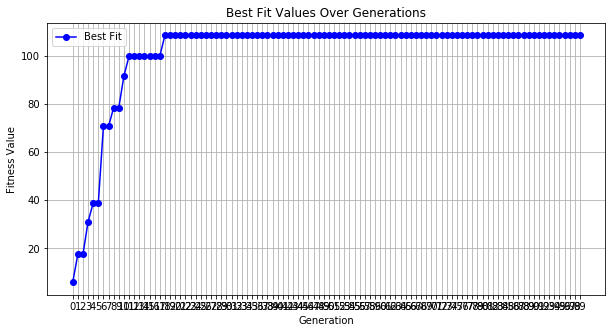

In [4]:

if __name__ == "__main__":
    generation_best_fits, best_chromosomes = genetic_algorithm()
    plot_best_fit(generation_best_fits) 

    

In [5]:
best_chromosomes[99]


'GGGGWWGUWG'

In [6]:
# Define optimization parameters in a dictionary
optimization_params = {
    "population_size": [6, 10, 50, 100, 500, 1000],
    "mutation_rate": [0.05, 0.1, 0.2],
    "crossover_probability": [0.8, 0.9, 1.0],
    "generations": [10, 50, 100],
}
# Initialize a list to hold results
results = []
fits = []

# Example: Iterate over each combination of parameters
for pop_size in optimization_params["population_size"]:
        for mutation_rate in optimization_params["mutation_rate"]:
            for crossover_prob in optimization_params["crossover_probability"]:
                for generations in optimization_params["generations"]:
                    fits = []
                    for i in range(3):
                        # Run your GA with the current parameters 
                        POPULATION_SIZE=pop_size
                        MUTATION_RATE=mutation_rate
                        CP = crossover_prob
                        GENERATIONS = generations
                        best_fits, best_chromosomes = genetic_algorithm()
                        # Store results
                        fits.append(best_fits[-1])
                    
                    result = {
                            "population_size": pop_size,
                            "mutation_rate": mutation_rate,
                            "crossover_probability": crossover_prob,
                            "generations": generations,
                            "best_fitness": sum(fits)/len(fits),
                            "best_chromosome": best_chromosomes[best_fits.index(max(best_fits))]
                    }
                    results.append(result)
                    print(result)

# Optional: Sort results by best fitness to identify the optimal parameter set
sorted_results = sorted(results, key=lambda x: x["best_fitness"], reverse=True)


{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.8, 'generations': 10, 'best_fitness': -11.047544363361482, 'best_chromosome': 'RWULDPURGP'}
{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.8, 'generations': 50, 'best_fitness': -5.428515819984336, 'best_chromosome': 'GPGUPLLWRL'}
{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.8, 'generations': 100, 'best_fitness': -11.636661836337902, 'best_chromosome': 'PDGPGGRPPL'}
{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.9, 'generations': 10, 'best_fitness': -8.760335513531947, 'best_chromosome': 'LDUURPWWUR'}
{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.9, 'generations': 50, 'best_fitness': -1.80342945320389, 'best_chromosome': 'LGPPUDWUGW'}
{'population_size': 6, 'mutation_rate': 0.05, 'crossover_probability': 0.9, 'generations': 100, 'best_fitness': -9.329933586903815, 'best_chromosome': 'RWRPRDWGDW'}
{'population_

In [7]:
from tabulate import tabulate

# Define headers for the table
headers = [
    "Population Size", "Mutation Rate", "Crossover Probability",
    "Generations", "Best Fitness", "Best Chromosome"
]

# Convert each result dictionary into a row for the table
table_data = [
    [
        result["population_size"], result["mutation_rate"], result["crossover_probability"],
        result["generations"], result["best_fitness"], result["best_chromosome"]
    ]
    for result in sorted_results
]

# Print the table
print(tabulate(table_data, headers=headers, tablefmt="grid"))


+-------------------+-----------------+-------------------------+---------------+----------------+-------------------+
|   Population Size |   Mutation Rate |   Crossover Probability |   Generations |   Best Fitness | Best Chromosome   |
+===================+=================+=========================+===============+================+===================+
|               100 |            0.1  |                     0.9 |            50 |     128.756    | GGGGWWUWWG        |
+-------------------+-----------------+-------------------------+---------------+----------------+-------------------+
|               100 |            0.2  |                     1   |            50 |     128.756    | GGGGWUWWWG        |
+-------------------+-----------------+-------------------------+---------------+----------------+-------------------+
|               500 |            0.05 |                     0.8 |           100 |     128.756    | GGGGWWUWWG        |
+-------------------+-----------------+---------

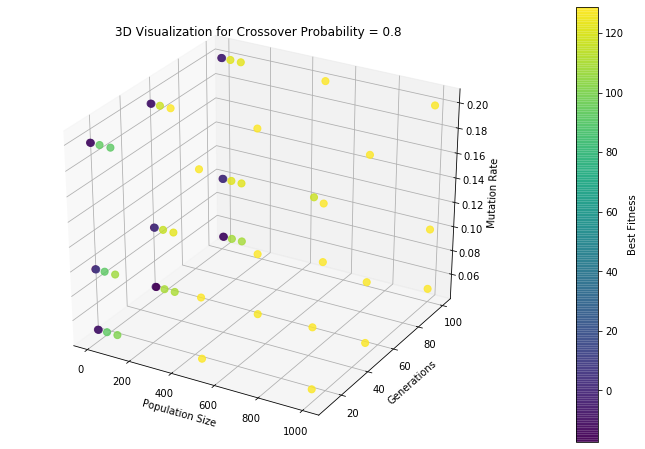

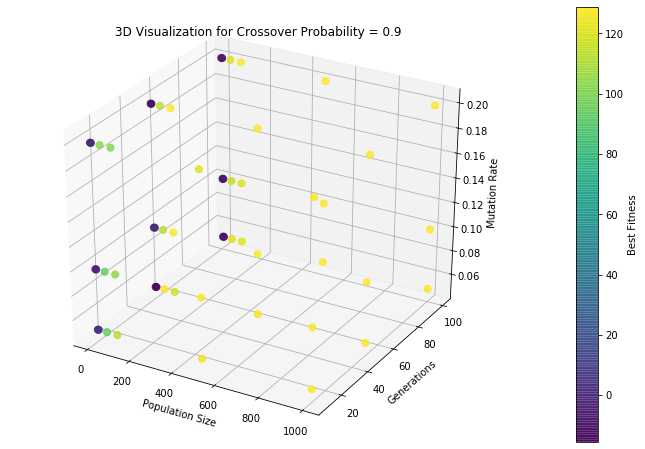

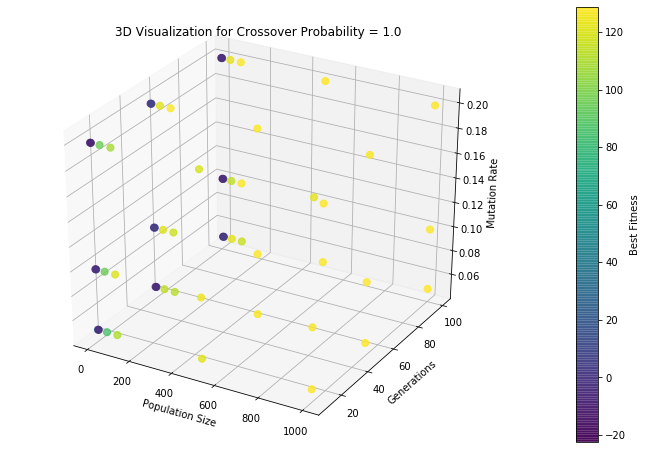

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

# Convert results into a DataFrame
df = pd.DataFrame(results)

# List of unique crossover probabilities
crossover_probs = df['crossover_probability'].unique()

# Create 3D scatter plots for each crossover probability
for cp in crossover_probs:
    # Filter data for the current crossover probability
    subset = df[df['crossover_probability'] == cp]
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot
    scatter = ax.scatter(
        subset['population_size'],  # X-axis
        subset['generations'],     # Y-axis
        subset['mutation_rate'],   # Z-axis
        c=subset['best_fitness'],  # Color by fitness
        cmap='viridis',            # Colormap
        s=50,                      # Marker size
        alpha=0.8                  # Transparency
    )
    
    # Add a color bar
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Best Fitness')
    
    # Set labels
    ax.set_title(f"3D Visualization for Crossover Probability = {cp}")
    ax.set_xlabel('Population Size')
    ax.set_ylabel('Generations')
    ax.set_zlabel('Mutation Rate')
    
    plt.show()


In [9]:
import csv
with open('output.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write each row of table_data to the file
    for row in table_data:
        writer.writerow(row)